This model is similar to model 22, the only change is that it switches out the carbohydrate estimator being Model 3 V3 DINOv2 to the RDInet inspired model 24.

Prerequisits

In [ ]:
!pip install -q keras-hub huggingface_hub scikit-learn joblib

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

Mounted at /content/drive
TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Paths and settings

In [ ]:
# =========================================================
# MODEL 26
# RGB-D carb estimator + predicted ingredients
# Model 22-style simple fusion head
# =========================================================

MODEL_NAME = "Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion"

MODEL26_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion"
)
MODEL26_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = MODEL26_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

# Model 24  carbohydrate estimator predictions
MODEL24_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor"
)

MODEL24_VERIFIED_DIR = MODEL24_DIR / "verified_prediction_exports"

# Reuse Model 24 / Model 23 prepared split CSVs
MODEL24_PREP_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_23_RDINet_3Level_DINOv2_RGB_DINOv2_depthcolor/prep_files"
)

train_csv = MODEL24_PREP_DIR / "train_model23.csv"
val_csv   = MODEL24_PREP_DIR / "val_model23.csv"
test_csv  = MODEL24_PREP_DIR / "test_model23.csv"

# Metadata with ingredient columns, needed to identify ingredient order
INGREDIENT_METADATA_CSV = Path(
    "/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/"
    "dish_carb_mass_ingredients_split_metadata.csv"
)

# Model 20 ingredient estimator
MODEL20_DIR = Path(
    "/content/drive/MyDrive/Speciale/Models/"
    "Model_20_DINOv2_base_ingredient_classifier"
)

MODEL20_FINAL_MODEL = MODEL20_DIR / "final_model.keras"

# Image settings for ingredient model
RGB_IMG_HEIGHT = 224
RGB_IMG_WIDTH = 224
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

# Fusion model settings
COMBINER_EPOCHS = 500
COMBINER_LR = 1e-3
COMBINER_BATCH_SIZE = 16

print("Model 26 dir:", MODEL26_DIR)
print("Model 24 dir:", MODEL24_DIR)
print("Model 20 dir:", MODEL20_DIR)

Model 26 dir: /content/drive/MyDrive/Speciale/Models/Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion
Model 24 dir: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor
Model 20 dir: /content/drive/MyDrive/Speciale/Models/Model_20_DINOv2_base_ingredient_classifier


Loading metadata

In [ ]:
train_df = pd.read_csv(train_csv)
val_df   = pd.read_csv(val_csv)
test_df  = pd.read_csv(test_csv)

for d in [train_df, val_df, test_df]:
    d["dish_id"] = d["dish_id"].astype(str).str.strip()
    d["rgb_path"] = d["rgb_path"].astype(str)
    d["total_carb"] = pd.to_numeric(d["total_carb"], errors="coerce").astype("float32")

    if "depth_path" in d.columns:
        d["depth_path"] = d["depth_path"].astype(str)

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)

display(train_df.head())

Train: (2419, 10)
Val:   (334, 10)
Test:  (507, 10)


,dish_id,total_carb,split,source_cafe,rgb_path,depth_path,rgb_exists,depth_exists,rgb_size,depth_size
0,dish_1556572657,2.268,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,412129,128124
1,dish_1556573514,1.219,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,432908,286439
2,dish_1556575014,3.906,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,409854,300120
3,dish_1556575083,5.760,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,396942,288910
4,dish_1556575124,0.952,train,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,True,404314,287977


Loading ingredient columns

In [ ]:
ingredient_meta_df = pd.read_csv(INGREDIENT_METADATA_CSV)
ingredient_cols = [c for c in ingredient_meta_df.columns if c.startswith("ingr_")]

if len(ingredient_cols) == 0:
    raise ValueError("No ingredient columns found. Expected columns starting with 'ingr_'.")

print("Number of ingredient columns:", len(ingredient_cols))
print("First 20 ingredient columns:")
print(ingredient_cols[:20])

Number of ingredient columns: 198
First 20 ingredient columns:
['ingr_almonds', 'ingr_apple', 'ingr_artichokes', 'ingr_arugula', 'ingr_asparagus', 'ingr_avocado', 'ingr_baby_carrots', 'ingr_bacon', 'ingr_bagels', 'ingr_banana_with_peel', 'ingr_basil', 'ingr_beef', 'ingr_beets', 'ingr_bell_peppers', 'ingr_berries', 'ingr_black_beans', 'ingr_blackberries', 'ingr_blue_cheese', 'ingr_blueberries', 'ingr_bok_choy']


Loading saved model 24 predictions

In [ ]:
def find_model24_prediction_csv(split_name):
    search_dirs = []

    if MODEL24_VERIFIED_DIR.exists():
        search_dirs.append(MODEL24_VERIFIED_DIR)

    search_dirs.append(MODEL24_DIR)

    candidates = []

    for search_dir in search_dirs:
        for pattern in [
            f"*{split_name}*.csv",
            f"**/*{split_name}*.csv",
        ]:
            candidates.extend(list(search_dir.glob(pattern)))

    candidates = sorted(set(candidates))

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"No Model 24 prediction CSV found for split '{split_name}'. "
            f"Searched in {search_dirs}"
        )

    print(f"\nCandidate files for {split_name}:")
    for i, p in enumerate(candidates):
        print(i, p)

    preferred_keywords = [
        "verified",
        "rdinet",
        "prediction",
        "predictions",
        "export",
        split_name,
    ]

    bad_keywords = [
        "comparison",
        "summary",
        "metric",
        "model25",
        "model_25",
        "model26",
        "model_26",
        "ingredient",
        "mass",
        "actual_mass",
    ]

    scored = []

    for p in candidates:
        name = p.name.lower()
        score = sum(k in name for k in preferred_keywords)
        score -= 10 * sum(k in name for k in bad_keywords)

        if "verified_prediction_exports" in str(p).lower():
            score += 5

        scored.append((score, p))

    scored = sorted(scored, key=lambda x: x[0], reverse=True)

    chosen = scored[0][1]
    print(f"Chosen {split_name} prediction CSV:", chosen)

    return chosen


def detect_prediction_column(df):
    preferred_cols = [
        "prediction",
        "pred",
        "y_pred",
        "rdinet_carb_pred",
        "model24_pred",
        "final_pred",
        "carb_pred",
        "predicted_carb",
        "carbohydrates_g",
    ]

    for col in preferred_cols:
        if col in df.columns:
            return col

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    pred_like_cols = [
        c for c in numeric_cols
        if "pred" in c.lower() or "prediction" in c.lower()
    ]

    if len(pred_like_cols) > 0:
        return pred_like_cols[0]

    raise ValueError(
        "Could not detect prediction column. Columns found:\n"
        + str(df.columns.tolist())
    )


def load_model24_predictions(split_name):
    csv_path = find_model24_prediction_csv(split_name)
    pred_df = pd.read_csv(csv_path)

    print(f"\nLoaded {split_name} prediction file:")
    print("Shape:", pred_df.shape)
    print("Columns:", pred_df.columns.tolist())

    if "dish_id" not in pred_df.columns:
        raise ValueError(f"'dish_id' missing in {csv_path}")

    pred_col = detect_prediction_column(pred_df)

    out = pred_df[["dish_id", pred_col]].copy()
    out = out.rename(columns={pred_col: "rdinet_carb_pred"})

    out["dish_id"] = out["dish_id"].astype(str).str.strip()
    out["rdinet_carb_pred"] = pd.to_numeric(
        out["rdinet_carb_pred"],
        errors="coerce"
    ).astype("float32")

    if out["rdinet_carb_pred"].isna().sum() > 0:
        raise ValueError(f"NaN values found in RDINet predictions for {split_name}")

    print("Using prediction column:", pred_col)
    display(out.head())

    return out


train_rdinet_pred_df = load_model24_predictions("train")
val_rdinet_pred_df   = load_model24_predictions("val")
test_rdinet_pred_df  = load_model24_predictions("test")


Candidate files for train:
0 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/model25_rdinet_predictions_train.csv
1 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_train_stage_1.csv
2 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_train_stage_2.csv
Chosen train prediction CSV: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_train_stage_1.csv

Loaded train prediction file:
Shape: (2419, 15)
Columns: ['dish_id', 'total_carb', 'split', 'source_cafe', 'rgb_path', 'depth_path', 'rgb_exists', 'depth_exists', 'rgb_size', 'depth_size', 'rdinet_carb_pred', 'rdinet_abs_error', 'rdinet_

,dish_id,rdinet_carb_pred
0,dish_1556572657,1.589515
1,dish_1556573514,2.321530
2,dish_1556575014,2.456608
3,dish_1556575083,3.129067
4,dish_1556575124,1.540793



Candidate files for val:
0 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/model25_rdinet_predictions_val.csv
1 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_val_stage_1.csv
2 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_val_stage_2.csv
Chosen val prediction CSV: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_val_stage_1.csv

Loaded val prediction file:
Shape: (334, 15)
Columns: ['dish_id', 'total_carb', 'split', 'source_cafe', 'rgb_path', 'depth_path', 'rgb_exists', 'depth_exists', 'rgb_size', 'depth_size', 'rdinet_carb_pred', 'rdinet_abs_error', 'rdinet_signed_error', 

,dish_id,rdinet_carb_pred
0,dish_1559149615,0.494092
1,dish_1559149650,6.910615
2,dish_1559149688,0.720359
3,dish_1559149719,13.181520
4,dish_1559838214,0.896668



Candidate files for test:
0 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/model25_rdinet_predictions_test.csv
1 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_test_stage_1.csv
2 /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_test_stage_2.csv
Chosen test prediction CSV: /content/drive/MyDrive/Speciale/Models/Model_24_RDINet_3Level_DINOv2_large_RGB_DINOv2_large_depthcolor/verified_prediction_exports/verified_rdinet_predictions_test_stage_1.csv

Loaded test prediction file:
Shape: (507, 15)
Columns: ['dish_id', 'total_carb', 'split', 'source_cafe', 'rgb_path', 'depth_path', 'rgb_exists', 'depth_exists', 'rgb_size', 'depth_size', 'rdinet_carb_pred', 'rdinet_abs_error', 'rdinet_signed_e

,dish_id,rdinet_carb_pred
0,dish_1556575327,11.217070
1,dish_1557861216,1.343749
2,dish_1557862345,1.691291
3,dish_1557862696,2.287569
4,dish_1557862738,2.843851


Merging dataframes

In [ ]:
def merge_rdinet_predictions(base_df, pred_df, split_name):
    base = base_df.copy()
    base["dish_id"] = base["dish_id"].astype(str).str.strip()

    pred = pred_df.copy()
    pred["dish_id"] = pred["dish_id"].astype(str).str.strip()

    merged = base.merge(
        pred,
        on="dish_id",
        how="left",
        validate="one_to_one"
    )

    missing = merged["rdinet_carb_pred"].isna().sum()
    print(f"{split_name} missing RDINet predictions:", missing)

    if missing > 0:
        display(merged[merged["rdinet_carb_pred"].isna()].head(20))
        raise ValueError(f"Missing RDINet predictions for {split_name}")

    return merged.reset_index(drop=True)


train_df = merge_rdinet_predictions(train_df, train_rdinet_pred_df, "train")
val_df   = merge_rdinet_predictions(val_df, val_rdinet_pred_df, "val")
test_df  = merge_rdinet_predictions(test_df, test_rdinet_pred_df, "test")

display(train_df[["dish_id", "total_carb", "rdinet_carb_pred"]].head())

train missing RDINet predictions: 0
val missing RDINet predictions: 0
test missing RDINet predictions: 0


,dish_id,total_carb,rdinet_carb_pred
0,dish_1556572657,2.268,1.589515
1,dish_1556573514,1.219,2.321530
2,dish_1556575014,3.906,2.456608
3,dish_1556575083,5.760,3.129067
4,dish_1556575124,0.952,1.540793


Checking correct model 24 load in

In [ ]:
def compute_pmae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    mae = np.mean(np.abs(y_true - y_pred))
    mean_true = np.mean(y_true)

    return float((mae / mean_true) * 100.0)


def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mse": float(mean_squared_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
        "pmae": float(compute_pmae(y_true, y_pred)),
        "mean_true_carb": float(np.mean(y_true)),
    }


model24_train_metrics = compute_metrics(
    train_df["total_carb"],
    train_df["rdinet_carb_pred"]
)

model24_val_metrics = compute_metrics(
    val_df["total_carb"],
    val_df["rdinet_carb_pred"]
)

model24_test_metrics = compute_metrics(
    test_df["total_carb"],
    test_df["rdinet_carb_pred"]
)

print("Model 24 baseline train:", model24_train_metrics)
print("Model 24 baseline val:  ", model24_val_metrics)
print("Model 24 baseline test: ", model24_test_metrics)

Model 24 baseline train: {'mae': 1.725771427154541, 'mse': 11.46976375579834, 'rmse': 3.3867039663658733, 'r2': 0.978520929813385, 'pmae': 8.88852596282959, 'mean_true_carb': 19.415721893310547}
Model 24 baseline val:   {'mae': 4.404017925262451, 'mse': 38.88702392578125, 'rmse': 6.235946113123593, 'r2': 0.8292625546455383, 'pmae': 23.430160522460938, 'mean_true_carb': 18.796363830566406}
Model 24 baseline test:  {'mae': 4.719059467315674, 'mse': 53.89215850830078, 'rmse': 7.34112787712493, 'r2': 0.8224477171897888, 'pmae': 23.974580764770508, 'mean_true_carb': 19.683595657348633}


Loading model 20 ingredient estimator

In [ ]:
if not MODEL20_FINAL_MODEL.exists():
    raise FileNotFoundError(f"Could not find Model 20 final model at: {MODEL20_FINAL_MODEL}")

ingredient_model = keras.models.load_model(MODEL20_FINAL_MODEL)

tf.config.optimizer.set_jit(False)

try:
    ingredient_model.jit_compile = False
except Exception as e:
    print("Could not set ingredient_model.jit_compile directly:", e)

ingredient_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    jit_compile=False,
    run_eagerly=False
)

ingredient_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 464 variables whereas the saved optimizer has 454 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "rgb_only_dinov2_base_ingredient_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_image_converter          │ (None, 224, 224, 3)    │             0 │
│ (DINOV2ImageConverter)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_backbone                 │ (None, 257, 768)       │    86,777,856 │
│ (DINOV2Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 257, 768)       │         1,536 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_pool                      │ (None, 768)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ingredient_output (Dense)       │ (None, 198)            │        25,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,034,694 (332.01 MB)

 Trainable params: 85,982,534 (328.00 MB)

 Non-trainable params: 1,052,160 (4.01 MB)

Building RGB dataset for ingredient prediction

In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=RGB_IMG_HEIGHT,
        target_width=RGB_IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_rgb_for_ingredient_prediction(rgb_path):
    rgb = load_rgb_image(rgb_path)
    return {"rgb_input": rgb}


def make_ingredient_prediction_dataset(dataframe, batch_size=BATCH_SIZE):
    rgb_paths = dataframe["rgb_path"].astype(str).values

    ds = tf.data.Dataset.from_tensor_slices(rgb_paths)
    ds = ds.map(load_rgb_for_ingredient_prediction, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ingredient_dataset = make_ingredient_prediction_dataset(train_df, batch_size=BATCH_SIZE)
val_ingredient_dataset   = make_ingredient_prediction_dataset(val_df, batch_size=BATCH_SIZE)
test_ingredient_dataset  = make_ingredient_prediction_dataset(test_df, batch_size=BATCH_SIZE)

for batch_inputs in train_ingredient_dataset.take(1):
    print("Input keys:", batch_inputs.keys())
    print("RGB shape:", batch_inputs["rgb_input"].shape)

Input keys: dict_keys(['rgb_input'])
RGB shape: (16, 224, 224, 3)


Generating ingredient predictions

In [ ]:
train_ingr_preds = ingredient_model.predict(train_ingredient_dataset, verbose=1)
val_ingr_preds   = ingredient_model.predict(val_ingredient_dataset, verbose=1)
test_ingr_preds  = ingredient_model.predict(test_ingredient_dataset, verbose=1)

print("Train ingredient preds shape:", train_ingr_preds.shape)
print("Val ingredient preds shape:  ", val_ingr_preds.shape)
print("Test ingredient preds shape: ", test_ingr_preds.shape)

expected_num_ingredients = len(ingredient_cols)

if train_ingr_preds.shape[1] != expected_num_ingredients:
    raise ValueError(
        f"Ingredient prediction size mismatch. "
        f"Model output has {train_ingr_preds.shape[1]} columns, "
        f"but ingredient metadata has {expected_num_ingredients} ingredient columns."
    )

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)


151/152 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step 

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


152/152 ━━━━━━━━━━━━━━━━━━━━ 1382s 9s/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 186s 9s/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 282s 9s/step
Train ingredient preds shape: (2419, 198)
Val ingredient preds shape:   (334, 198)
Test ingredient preds shape:  (507, 198)


Creating combiner CSV

In [ ]:
pred_ingredient_cols = [f"pred_{col}" for col in ingredient_cols]

base_cols = ["dish_id", "total_carb", "split"]

if "source_cafe" in train_df.columns:
    base_cols.append("source_cafe")

train_combiner_df = train_df[base_cols].copy().reset_index(drop=True)
val_combiner_df   = val_df[base_cols].copy().reset_index(drop=True)
test_combiner_df  = test_df[base_cols].copy().reset_index(drop=True)

train_combiner_df["rdinet_carb_pred"] = train_df["rdinet_carb_pred"].values.astype("float32")
val_combiner_df["rdinet_carb_pred"]   = val_df["rdinet_carb_pred"].values.astype("float32")
test_combiner_df["rdinet_carb_pred"]  = test_df["rdinet_carb_pred"].values.astype("float32")

for i, col in enumerate(pred_ingredient_cols):
    train_combiner_df[col] = train_ingr_preds[:, i].astype("float32")
    val_combiner_df[col]   = val_ingr_preds[:, i].astype("float32")
    test_combiner_df[col]  = test_ingr_preds[:, i].astype("float32")

train_combiner_csv = PREP_DIR / "train_combiner_features_rdinet_predicted_ingredients.csv"
val_combiner_csv   = PREP_DIR / "val_combiner_features_rdinet_predicted_ingredients.csv"
test_combiner_csv  = PREP_DIR / "test_combiner_features_rdinet_predicted_ingredients.csv"

train_combiner_df.to_csv(train_combiner_csv, index=False)
val_combiner_df.to_csv(val_combiner_csv, index=False)
test_combiner_df.to_csv(test_combiner_csv, index=False)

print("Saved combiner feature CSVs:")
print(train_combiner_csv)
print(val_combiner_csv)
print(test_combiner_csv)

display(train_combiner_df.head())

/tmp/ipykernel_384/3795115976.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_combiner_df[col] = train_ingr_preds[:, i].astype("float32")
/tmp/ipykernel_384/3795115976.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  val_combiner_df[col]   = val_ingr_preds[:, i].astype("float32")
/tmp/ipykernel_384/3795115976.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(a

Saved combiner feature CSVs:
/content/drive/MyDrive/Speciale/Models/Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion/prep_files/train_combiner_features_rdinet_predicted_ingredients.csv
/content/drive/MyDrive/Speciale/Models/Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion/prep_files/val_combiner_features_rdinet_predicted_ingredients.csv
/content/drive/MyDrive/Speciale/Models/Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion/prep_files/test_combiner_features_rdinet_predicted_ingredients.csv


,dish_id,total_carb,split,source_cafe,rdinet_carb_pred,pred_ingr_almonds,pred_ingr_apple,pred_ingr_artichokes,pred_ingr_arugula,pred_ingr_asparagus,...,pred_ingr_wheat_berry,pred_ingr_wheat_bread,pred_ingr_white_beans,pred_ingr_white_rice,pred_ingr_white_wine,pred_ingr_wild_rice,pred_ingr_wine,pred_ingr_yam,pred_ingr_yogurt,pred_ingr_zucchini
0,dish_1556572657,2.268,train,cafe1,1.589515,0.003237,4.618276e-07,2.267691e-06,6.570926e-10,0.000003,...,1.366452e-07,1.952985e-08,2.519221e-12,2.138120e-07,2.997094e-11,2.286739e-13,1.978370e-09,2.971382e-08,1.988422e-06,0.000002
1,dish_1556573514,1.219,train,cafe1,2.321530,0.001400,4.420539e-03,3.784934e-03,7.241180e-04,0.021378,...,8.600491e-05,7.758379e-06,3.372128e-06,1.698756e-05,2.777386e-07,4.196254e-08,3.065954e-04,4.087875e-05,1.062088e-03,0.000753
2,dish_1556575014,3.906,train,cafe1,2.456608,0.001655,2.432371e-07,2.519475e-06,2.510476e-09,0.000003,...,9.413976e-07,9.767230e-09,2.003109e-11,8.791426e-07,2.489979e-10,1.605229e-12,1.032282e-08,5.114276e-08,9.578351e-07,0.000005
3,dish_1556575083,5.760,train,cafe1,3.129067,0.000138,9.747376e-06,3.124530e-08,1.052347e-06,0.000001,...,3.201241e-06,8.337795e-10,2.432278e-11,9.107595e-07,5.040648e-11,9.297725e-13,3.563262e-07,2.200898e-05,5.886282e-08,0.000004
4,dish_1556575124,0.952,train,cafe1,1.540793,0.000085,3.147241e-04,3.101359e-04,8.202580e-07,0.000308,...,6.443245e-06,1.591473e-06,1.058992e-06,1.114436e-05,7.391897e-09,4.204719e-10,2.756730e-05,3.691517e-05,4.968368e-05,0.000944


In [ ]:
X_train_rgb = train_combiner_df[["rdinet_carb_pred"]].values.astype("float32")
X_val_rgb   = val_combiner_df[["rdinet_carb_pred"]].values.astype("float32")
X_test_rgb  = test_combiner_df[["rdinet_carb_pred"]].values.astype("float32")

X_train_ingr = train_combiner_df[pred_ingredient_cols].values.astype("float32")
X_val_ingr   = val_combiner_df[pred_ingredient_cols].values.astype("float32")
X_test_ingr  = test_combiner_df[pred_ingredient_cols].values.astype("float32")

y_train = train_combiner_df["total_carb"].values.astype("float32")
y_val   = val_combiner_df["total_carb"].values.astype("float32")
y_test  = test_combiner_df["total_carb"].values.astype("float32")

print("X_train_rgb:", X_train_rgb.shape)
print("X_train_ingr:", X_train_ingr.shape)
print("y_train:", y_train.shape)

X_train_rgb: (2419, 1)
X_train_ingr: (2419, 198)
y_train: (2419,)


In [ ]:
rgb_scaler = StandardScaler()

X_train_rgb_scaled = rgb_scaler.fit_transform(X_train_rgb).astype("float32")
X_val_rgb_scaled   = rgb_scaler.transform(X_val_rgb).astype("float32")
X_test_rgb_scaled  = rgb_scaler.transform(X_test_rgb).astype("float32")

rgb_scaler_path = MODEL26_DIR / "rdinet_prediction_scaler.joblib"
joblib.dump(rgb_scaler, rgb_scaler_path)

print("Saved RDINet prediction scaler to:", rgb_scaler_path)
print("Scaled train mean:", X_train_rgb_scaled.mean())
print("Scaled train std:", X_train_rgb_scaled.std())

Saved RDINet prediction scaler to: /content/drive/MyDrive/Speciale/Models/Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion/rdinet_prediction_scaler.joblib
Scaled train mean: -3.1539455e-09
Scaled train std: 1.0


Model 26 architecture

In [ ]:
tf.keras.backend.clear_session()

rdinet_input = keras.Input(shape=(1,), name="rdinet_pred_input")
ingredient_input = keras.Input(
    shape=(len(pred_ingredient_cols),),
    name="ingredient_input"
)

rdinet_branch = layers.Dense(16, activation="relu")(rdinet_input)
rdinet_branch = layers.Dropout(0.1)(rdinet_branch)

ingredient_branch = layers.Dense(128, activation="relu")(ingredient_input)
ingredient_branch = layers.Dropout(0.2)(ingredient_branch)
ingredient_branch = layers.Dense(64, activation="relu")(ingredient_branch)

fusion = layers.Concatenate()([rdinet_branch, ingredient_branch])
fusion = layers.Dense(64, activation="relu")(fusion)
fusion = layers.Dropout(0.2)(fusion)
fusion = layers.Dense(32, activation="relu")(fusion)

output = layers.Dense(
    1,
    activation="linear",
    name="carb_output"
)(fusion)

model26 = keras.Model(
    inputs=[rdinet_input, ingredient_input],
    outputs=output,
    name="model_26_rdinet_ingredient_neural_combiner"
)

model26.compile(
    optimizer=keras.optimizers.Adam(learning_rate=COMBINER_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse"),
    ]
)

model26.summary()

Model: "model_26_rdinet_ingredient_neural_combiner"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ingredient_input    │ (None, 198)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rdinet_pred_input   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     25,472 │ ingredient_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         32 │ rdinet_pred_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 16)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      5,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ carb_output (Dense) │ (None, 1)         │         33 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,057 (160.38 KB)

 Trainable params: 41,057 (160.38 KB)

 Non-trainable params: 0 (0.00 B)

Training model 26

In [ ]:
model26_best_path = MODEL26_DIR / "best_model26_rdinet_predicted_ingredients.weights.h5"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(model26_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=200,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=150,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

history_model26 = model26.fit(
    {
        "rdinet_pred_input": X_train_rgb_scaled,
        "ingredient_input": X_train_ingr,
    },
    y_train,
    validation_data=(
        {
            "rdinet_pred_input": X_val_rgb_scaled,
            "ingredient_input": X_val_ingr,
        },
        y_val
    ),
    epochs=COMBINER_EPOCHS,
    batch_size=COMBINER_BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/500
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 654.0572 - mae: 16.2941 - mse: 654.0572
Epoch 1: val_loss improved from None to 87.61938, saving model to /content/drive/MyDrive/Speciale/Models/Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion/best_model26_rdinet_predicted_ingredients.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion/best_model26_rdinet_predicted_ingredients.weights.h5
152/152 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 556.7416 - mae: 12.6756 - mse: 556.7416 - val_loss: 87.6194 - val_mae: 7.1523 - val_mse: 87.6194 - learning_rate: 0.0010
Epoch 2/500
133/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 233.6927 - mae: 7.0464 - mse: 233.6927
Epoch 2: val_loss improved from 87.61938 to 57.16416, saving model to /content/drive/MyDrive/Speciale/Models/Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion/best_model26_rdinet_predicted_ingredients.weig

Plotting training and validation curves

Loaded best Model 26 weights from: /content/drive/MyDrive/Speciale/Models/Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion/best_model26_rdinet_predicted_ingredients.weights.h5


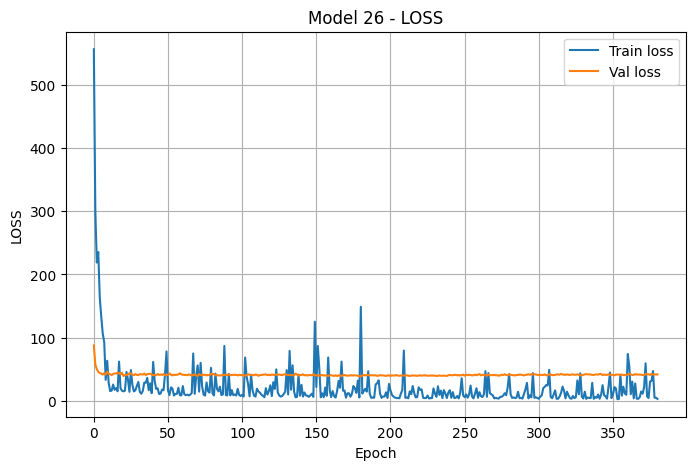

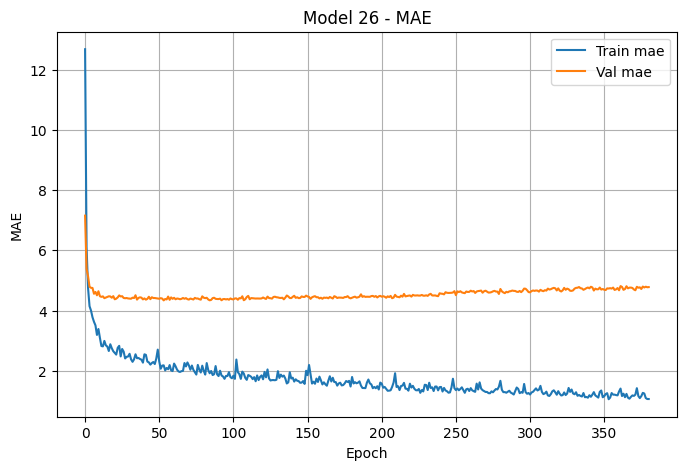

In [ ]:
model26.load_weights(str(model26_best_path))
print("Loaded best Model 26 weights from:", model26_best_path)

for metric in ["loss", "mae"]:
    plt.figure(figsize=(8, 5))
    plt.plot(history_model26.history[metric], label=f"Train {metric}")
    plt.plot(history_model26.history[f"val_{metric}"], label=f"Val {metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric.upper())
    plt.title(f"Model 26 - {metric.upper()}")
    plt.legend()
    plt.grid(True)
    plt.show()

Prediction with model 26

In [ ]:
train_preds = model26.predict(
    {
        "rdinet_pred_input": X_train_rgb_scaled,
        "ingredient_input": X_train_ingr,
    },
    verbose=1
).reshape(-1)

val_preds = model26.predict(
    {
        "rdinet_pred_input": X_val_rgb_scaled,
        "ingredient_input": X_val_ingr,
    },
    verbose=1
).reshape(-1)

test_preds = model26.predict(
    {
        "rdinet_pred_input": X_test_rgb_scaled,
        "ingredient_input": X_test_ingr,
    },
    verbose=1
).reshape(-1)

print("Train preds:", train_preds.shape)
print("Val preds:  ", val_preds.shape)
print("Test preds: ", test_preds.shape)

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Train preds: (2419,)
Val preds:   (334,)
Test preds:  (507,)


Result comparrison

In [ ]:
def build_metric_row(model_name, y_train, train_pred, y_val, val_pred, y_test, test_pred):
    train_metrics = compute_metrics(y_train, train_pred)
    val_metrics   = compute_metrics(y_val, val_pred)
    test_metrics  = compute_metrics(y_test, test_pred)

    return {
        "model": model_name,

        "train_mae": train_metrics["mae"],
        "train_mse": train_metrics["mse"],
        "train_rmse": train_metrics["rmse"],
        "train_r2": train_metrics["r2"],
        "train_pmae": train_metrics["pmae"],

        "val_mae": val_metrics["mae"],
        "val_mse": val_metrics["mse"],
        "val_rmse": val_metrics["rmse"],
        "val_r2": val_metrics["r2"],
        "val_pmae": val_metrics["pmae"],

        "test_mae": test_metrics["mae"],
        "test_mse": test_metrics["mse"],
        "test_rmse": test_metrics["rmse"],
        "test_r2": test_metrics["r2"],
        "test_pmae": test_metrics["pmae"],
    }


results = []

results.append(build_metric_row(
    "Model_24_RDINet_RGBD_baseline",
    y_train, train_combiner_df["rdinet_carb_pred"].values,
    y_val,   val_combiner_df["rdinet_carb_pred"].values,
    y_test,  test_combiner_df["rdinet_carb_pred"].values,
))

results.append(build_metric_row(
    "Model_26_RDINet_plus_predicted_ingredients_Model22_head",
    y_train, train_preds,
    y_val,   val_preds,
    y_test,  test_preds,
))

results_df = pd.DataFrame(results).sort_values(
    "val_mse",
    ascending=True
).reset_index(drop=True)

display(results_df)

results_csv = MODEL26_DIR / "model26_comparison_rdinet_vs_rdinet_plus_predicted_ingredients.csv"
results_df.to_csv(results_csv, index=False)

print("Saved results to:", results_csv)

,model,train_mae,train_mse,train_rmse,train_r2,train_pmae,val_mae,val_mse,val_rmse,val_r2,val_pmae,test_mae,test_mse,test_rmse,test_r2,test_pmae
0,Model_26_RDINet_plus_predicted_ingredients_Mod...,1.274621,12.403051,3.521797,0.976773,6.564893,4.428379,38.400410,6.196806,0.831399,23.559765,4.714498,53.029980,7.282169,0.825288,23.951406
1,Model_24_RDINet_RGBD_baseline,1.725771,11.469764,3.386704,0.978521,8.888526,4.404018,38.887024,6.235946,0.829263,23.430161,4.719059,53.892159,7.341128,0.822448,23.974581


Saved results to: /content/drive/MyDrive/Speciale/Models/Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion/model26_comparison_rdinet_vs_rdinet_plus_predicted_ingredients.csv


Saving final model

In [ ]:
final_model_path = MODEL26_DIR / "model26_rdinet_predicted_ingredients_combiner.keras"
model26.save(final_model_path)

print("Saved final Model 26 combiner to:", final_model_path)

Saved final Model 26 combiner to: /content/drive/MyDrive/Speciale/Models/Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion/model26_rdinet_predicted_ingredients_combiner.keras


Saving predictions

In [ ]:
train_results_df = train_combiner_df.copy()
val_results_df   = val_combiner_df.copy()
test_results_df  = test_combiner_df.copy()

train_results_df["model26_pred"] = train_preds
val_results_df["model26_pred"]   = val_preds
test_results_df["model26_pred"]  = test_preds

for df_out in [train_results_df, val_results_df, test_results_df]:
    df_out["model24_abs_error"] = np.abs(
        df_out["total_carb"].values - df_out["rdinet_carb_pred"].values
    )

    df_out["model26_abs_error"] = np.abs(
        df_out["total_carb"].values - df_out["model26_pred"].values
    )

    df_out["model26_signed_error"] = (
        df_out["model26_pred"].values - df_out["total_carb"].values
    )

train_predictions_csv = MODEL26_DIR / "model26_train_predictions.csv"
val_predictions_csv   = MODEL26_DIR / "model26_val_predictions.csv"
test_predictions_csv  = MODEL26_DIR / "model26_test_predictions.csv"

train_results_df.to_csv(train_predictions_csv, index=False)
val_results_df.to_csv(val_predictions_csv, index=False)
test_results_df.to_csv(test_predictions_csv, index=False)

print("Saved predictions:")
print(train_predictions_csv)
print(val_predictions_csv)
print(test_predictions_csv)

display(test_results_df.head())

Saved predictions:
/content/drive/MyDrive/Speciale/Models/Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion/model26_train_predictions.csv
/content/drive/MyDrive/Speciale/Models/Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion/model26_val_predictions.csv
/content/drive/MyDrive/Speciale/Models/Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion/model26_test_predictions.csv


,dish_id,total_carb,split,source_cafe,rdinet_carb_pred,pred_ingr_almonds,pred_ingr_apple,pred_ingr_artichokes,pred_ingr_arugula,pred_ingr_asparagus,...,pred_ingr_white_wine,pred_ingr_wild_rice,pred_ingr_wine,pred_ingr_yam,pred_ingr_yogurt,pred_ingr_zucchini,model26_pred,model24_abs_error,model26_abs_error,model26_signed_error
0,dish_1556575327,10.618,test,cafe1,11.217070,0.009016,0.000126,0.000004,2.917965e-07,0.000008,...,3.225009e-09,7.206626e-10,6.879346e-07,0.000013,1.457757e-07,0.000081,12.604896,0.599070,1.986896,1.986896
1,dish_1557861216,0.000,test,cafe1,1.343749,0.000008,0.000068,0.000049,2.531807e-07,0.000004,...,4.800575e-10,2.152842e-10,1.531195e-06,0.000007,3.537538e-04,0.000136,3.005884,1.343749,3.005884,3.005884
2,dish_1557862345,0.000,test,cafe1,1.691291,0.000251,0.000006,0.000220,7.137177e-07,0.000052,...,9.985113e-07,1.876729e-10,4.616502e-06,0.000087,1.361917e-03,0.000048,2.987994,1.691291,2.987994,2.987994
3,dish_1557862696,3.850,test,cafe1,2.287569,0.000012,0.000091,0.000028,4.340058e-08,0.000008,...,1.297786e-09,1.728327e-11,9.407403e-06,0.000038,3.801891e-03,0.000005,3.190567,1.562431,0.659432,-0.659432
4,dish_1557862738,0.000,test,cafe1,2.843851,0.000086,0.000062,0.000468,2.328329e-04,0.000453,...,3.225099e-06,2.230684e-07,2.086991e-04,0.003102,7.736096e-06,0.001087,3.550774,2.843851,3.550774,3.550774


Top 10 best and worst predictions

In [ ]:
best_10 = test_results_df.sort_values(
    "model26_abs_error",
    ascending=True
).head(10)

worst_10 = test_results_df.sort_values(
    "model26_abs_error",
    ascending=False
).head(10)

print("Top 10 best Model 26 predictions:")
display(best_10[[
    "dish_id",
    "total_carb",
    "rdinet_carb_pred",
    "model26_pred",
    "model26_abs_error",
]])

print("Top 10 worst Model 26 predictions:")
display(worst_10[[
    "dish_id",
    "total_carb",
    "rdinet_carb_pred",
    "model26_pred",
    "model26_abs_error",
]])

Top 10 best Model 26 predictions:


,dish_id,total_carb,rdinet_carb_pred,model26_pred,model26_abs_error
88,dish_1558639849,5.700000,3.717399,5.707396,0.007396
165,dish_1560456326,3.791613,2.777260,3.780807,0.010806
290,dish_1562790824,19.273878,20.973114,19.288246,0.014368
76,dish_1558635400,5.000000,2.581114,5.041260,0.041260
470,dish_1566838378,49.073997,49.092083,49.023098,0.050900
353,dish_1564160043,48.020000,48.246067,48.075855,0.055855
308,dish_1563295044,25.845209,25.030556,25.919426,0.074217
265,dish_1562690950,24.826828,22.521585,24.728077,0.098751
396,dish_1565035802,14.785000,14.872786,14.888848,0.103848
238,dish_1561739238,37.556999,38.071476,37.673977,0.116978


Top 10 worst Model 26 predictions:


,dish_id,total_carb,rdinet_carb_pred,model26_pred,model26_abs_error
178,dish_1560801020,61.690983,26.610445,27.619707,34.071274
177,dish_1560800988,61.249092,30.806494,29.437887,31.811205
454,dish_1566501594,54.281998,23.460995,23.956635,30.325363
424,dish_1565894910,67.945007,38.014194,38.422321,29.522686
326,dish_1563566939,48.869175,22.505318,19.889605,28.979570
327,dish_1563566965,56.243797,32.139458,28.716572,27.527225
179,dish_1560801041,63.245892,36.962601,36.204941,27.040951
325,dish_1563566909,46.750000,21.361557,21.236177,25.513823
149,dish_1560367952,45.956913,21.766483,20.663830,25.293083
247,dish_1562009934,62.243580,39.973431,37.037395,25.206184


Checking model 22 and model 26 was on the same test set

In [ ]:
model22_preds = pd.read_csv("/content/drive/MyDrive/Speciale/Models/Model_22_Carbohydrate_estimator_plus_ingredient_estimator/model22_test_predictions.csv")
model26_preds = pd.read_csv("/content/drive/MyDrive/Speciale/Models/Model_26_RDINet_RGBD_plus_predicted_ingredients_simple_fusion/model26_test_predictions.csv")

model22_preds["dish_id"] = model22_preds["dish_id"].astype(str).str.strip()
model26_preds["dish_id"] = model26_preds["dish_id"].astype(str).str.strip()

merged_compare = model22_preds.merge(
    model26_preds,
    on="dish_id",
    suffixes=("_m22", "_m26")
)

print("Overlapping dishes:", len(merged_compare))
print("Model 22 overlap MSE:", np.mean((merged_compare["total_carb_m22"] - merged_compare["model22_pred"]) ** 2))
print("Model 26 overlap MSE:", np.mean((merged_compare["total_carb_m26"] - merged_compare["model26_pred"]) ** 2))

Overlapping dishes: 507
Model 22 overlap MSE: 50.89293105514814
Model 26 overlap MSE: 53.0299809607173


I was a bit confused as to why Model 26 didnt perform better, but it seems like model 22 and its simpler carbohydrate estimator was better complimented by the ingredient estimator than Model 24, which performed slightly better on the test set when just comparing Model 3 V3 and Model 24. It can be seen that they are being evaluated on exactly the same test set and that Model 22 continues to be the best performing model.